# S2-1 ブートストラップ法によるゼロカーブ構築

## 学習目標

- ゼロレート・フォワードレート・パーレートの三者が、同じ割引係数から導かれる別表現であることを式で示せる
- パー債が価格1になる条件を連立方程式として書き下し、それを三角行列の前進代入として解けることを理解する
- パー利回りからのブートストラップをスクラッチで実装し、`bondlab.curve.bootstrap_par` と一致することを確認できる
- デポジット（単利）と債券（複利）が混在する入力へブートストラップを拡張できる
- QuantLib の `DiscountCurve` / `PiecewiseLogLinearDiscount` と突合し、時間軸（year fraction）を揃えれば補間ロジックが一致することを確認できる
- 入力パー利回りへのショックが、逐次求解を通じて長期ゾーンのゼロレートへ伝播する様子を可視化できる

## 実務での位置づけ（ファンドはどう稼ぐか）

ゼロカーブは、金利デスク・運用会社・RVファンドのすべての計算の出発点になります。債券・スワップ・先物・オプションのどれを評価するにも、まず市場で観測できるパー利回りやスワップレートから割引係数を復元しなければ、キャッシュフローを現在価値に割り戻せません。ブートストラップはこの復元を行う最も基本的な手続きで、フロントのクオンツが担うカーブ構築の入口にあたります。ここが狂うと、その日の全ポジションの時価評価（マーク）とP&L、DV01などのリスク量がまとめてずれます。

収益との繋がりは間接的に見えて、実は直接的です。マーケットメイクのデスクは、このカーブから理論値を引き、そこにビッド・オファースプレッドを乗せて値付けします。相対価値ファンドは、同じカーブから各銘柄の「あるべき価格」を出し、市場価格との乖離（rich/cheap）を測って割安を買い割高を売ります。乖離の計測はカーブの正しさが前提なので、ブートストラップの精度がそのまま裁定機会の見え方を左右します。キャリー戦略でも、保有債の利息とレポ調達コストの差を評価するために、期間ごとの割引・フォワードが要ります。

具体的な場面としては、朝の値洗いでその日のゼロカーブを引き直し、保有債の理論価格・アクルード・キャリーを再計算する、といった日次業務が典型です。ゼロ・フォワード・パーが同じ割引係数の別表現だと理解しておくと、パー利回りしか気配が立たない年限でもフォワードを取り出してヘッジや先渡し評価に使えます。この土台がないと、価格を付けることも、リスクを測ることも、乖離を裁定することもできません。以降の補間・パラメトリックフィット・マルチカーブは、すべてこのブートストラップの上に積み上がります。


## 理論

### ゼロレート・フォワードレート・パーレートの関係

割引カーブ $DF(t)$ を土台に置く。$DF(t)$ は時点 $t$ に受け取る1単位の現在価値であり、
ここから三つのレートがすべて定まる。表現が三つあるだけで、情報量は $DF(t)$ 一本と等しい。

**ゼロレート（zero rate）** $z(t)$ は、$t$ までの単一キャッシュフローに対する利回りである。
連続複利で定義すると

$$
DF(t) = e^{-z(t)\,t}
\quad\Longleftrightarrow\quad
z(t) = -\frac{\ln DF(t)}{t}.
$$

**フォワードレート（forward rate）** $f(t_1, t_2)$ は、いま約定して将来区間 $[t_1, t_2]$ に
適用される金利である。無裁定より、$t_1$ まで割り引いてから区間で運用した結果が $t_2$ 割引に
一致するので、

$$
DF(t_2) = DF(t_1)\, e^{-f(t_1,t_2)\,(t_2 - t_1)}
\quad\Longleftrightarrow\quad
f(t_1, t_2) = \frac{\ln DF(t_1) - \ln DF(t_2)}{t_2 - t_1}.
$$

区間を $t_2 \to t_1$ と縮めた極限が瞬間フォワード $f(t) = -\,\mathrm{d}\ln DF(t)/\mathrm{d}t$ で、
ゼロレートはその平均 $z(t) = \frac{1}{t}\int_0^t f(u)\,\mathrm{d}u$ にあたる。つまりゼロは
フォワードの累積平均であり、フォワードが上向きならゼロもそれに引かれて上向く。

**パーレート（par rate）** $c_n$ は、年限 $t_n$ の標準クーポン債が額面（パー）で取引される
ときのクーポン率である。年 $f$ 回払い・額面1として、価格がちょうど1になる条件から

$$
1 = \frac{c_n}{f} \sum_{k=1}^{n} DF(t_k) + DF(t_n)
\quad\Longleftrightarrow\quad
c_n = f\,\frac{1 - DF(t_n)}{\sum_{k=1}^{n} DF(t_k)}.
$$

パーレートはクーポン全体にわたる割引の加重平均的な利回りであり、ゼロレートとは別物である。
右上がりのカーブではクーポンが早い時点の低いゼロを含むため、$c_n < z(t_n)$ となる。

### ブートストラップの原理：連立方程式を三角化する

カーブ構築の入力は、通常ゼロレートではなくパー利回りである（S0-2 で見たとおり、市場が
直接クオートするのはパーやスワップレートであってゼロではない）。**ブートストラップ（bootstrap）**
は、パー利回りの列 $\{c_1, \dots, c_N\}$ から割引係数の列 $\{DF(t_1), \dots, DF(t_N)\}$ を
逐次に**剥ぎ取る（strip）**手続きである。

テナーが等間隔グリッド（$t_k = k/f$）に載っているとする。各テナーのパー債が価格1になる
条件を全テナー分並べると、$DF(t_i)$ を未知数とする連立方程式になる。

$$
\begin{aligned}
1 &= \tfrac{c_1}{f} DF(t_1) + DF(t_1) \\
1 &= \tfrac{c_2}{f}\bigl(DF(t_1) + DF(t_2)\bigr) + DF(t_2) \\
1 &= \tfrac{c_3}{f}\bigl(DF(t_1) + DF(t_2) + DF(t_3)\bigr) + DF(t_3) \\
  &\ \ \vdots
\end{aligned}
$$

第 $i$ 式には $DF(t_1), \dots, DF(t_i)$ しか現れない。係数行列を $DF$ ベクトルへの作用として
見ると**下三角**であり、上から順に前進代入（forward substitution）で一意に解ける。第 $i$ 式を
$DF(t_i)$ について解くと、

$$
DF(t_i) = \frac{1 - \dfrac{c_i}{f}\displaystyle\sum_{k=1}^{i-1} DF(t_k)}{1 + \dfrac{c_i}{f}}.
$$

分子の総和は「一つ前までに確定した割引係数の累積」である。これを走らせる変数（running sum）
として持ち回れば、1テナーあたり $O(1)$ でカーブ全体が $O(N)$ で構築できる。逐次求解と
連立方程式の三角化は同じ計算を別の言葉で述べたものである。

### 誤差の長期ゾーンへの伝播

前進代入の各段は、前段までの $DF$ の累積に依存する。したがって短いテナーのパー利回りに
誤差 $\delta c_j$ が乗ると、その誤差は $DF(t_j)$ を汚し、以降の running sum を通じて
$DF(t_{j+1}), DF(t_{j+2}), \dots$ すべてに繰り越される。カーブの長期端は、それより手前の
全入力の誤差を積み上げた位置に立つ。これはブートストラップが持つ構造的な性質で、
短期の1点のクオートずれが長期ゾーンのゼロレートに残り続ける理由である。この伝播は
後半の演習で数値的に確認する。

**数値例**：本文のグリッド（年1回払い、パー利回り $c_1=3.000\%,\ c_2=3.167\%,\ c_3=3.333\%$）を剥ぎ取ると、まず $DF(t_1)=1/(1+0.03)=0.970874$、$DF(t_2)=0.939505$ が確定します。3年目は前進代入で $DF(t_3)=\dfrac{1-0.03333\,(0.970874+0.939505)}{1+0.03333}=\dfrac{0.936321}{1.033333}=0.906117$ となります。

**数値例**：この $DF(t_1)=0.970874$ からゼロレートは $z(t_1)=-\ln(0.970874)/1=2.956\%$、1年フォワードは $f(1,2)=\ln 0.970874-\ln 0.939505=3.284\%$ です。右上がりのカーブなので、限界金利であるフォワードが平均金利であるゼロを上回ります。


## スクラッチ実装

### パー利回りからのブートストラップ

前進代入の式をそのまま実装する。累積割引を `running` に持ち、テナーごとに更新する。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `bootstrap_scratch(tenors, par_rates, freq)` | テナー配列, パー利回り配列, 年間払回数 | `(times, dfs)` の組 | 前進代入でパー利回りから割引係数を剥ぎ取る |
| `par_from_curve(times, dfs, freq)` | node 年数, 割引係数, 年間払回数 | パーレート配列 | 割引係数から各テナーのパーレートを逆算する |
| `bootstrap_with_deposits(depo, bonds, freq)` | デポ `(t, r)` 列, 債券 `(t, c)` 列, 年間払回数 | `(times, dfs)` の組 | 単利デポ＋複利債券の混在入力を剥ぎ取る |

In [1]:
import numpy as np
import pandas as pd

import bondlab
from bondlab import curve as blcurve

np.random.seed(0)
print("bondlab version:", bondlab.__version__)


def bootstrap_scratch(tenors, par_rates, freq=1):
    """パー利回りから割引係数を前進代入で剥ぎ取る。

    等間隔グリッド（1/freq 刻み）を仮定し、各テナーのパー債が価格1になる
    条件 DF(t_i) = (1 - (c_i/f) Σ_{k<i} DF(t_k)) / (1 + c_i/f) を順に解く。
    """
    tenors = np.asarray(tenors, dtype=float)
    par = np.asarray(par_rates, dtype=float)
    dfs = np.empty_like(tenors)
    running = 0.0  # 一つ前までに確定した DF の累積
    for i, (t, c) in enumerate(zip(tenors, par)):
        cpn = c / freq
        dfs[i] = (1.0 - cpn * running) / (1.0 + cpn)
        running += dfs[i]
    return tenors, dfs


def par_from_curve(times, dfs, freq=1):
    """割引係数から各テナーのパーレート c_n = f(1 - DF_n)/Σ_{k≤n} DF_k を逆算する。"""
    dfs = np.asarray(dfs, dtype=float)
    cum = np.cumsum(dfs)
    return freq * (1.0 - dfs) / cum

bondlab version: 0.0.1


等間隔グリッド（年1回払い、10年まで）で右上がりのパー利回りを用意し、剥ぎ取る。

In [2]:
grid = np.arange(1.0, 11.0)
par_in = np.linspace(0.030, 0.045, grid.size)

times, dfs = bootstrap_scratch(grid, par_in, freq=1)

table = pd.DataFrame({
    "テナー(年)": grid,
    "パー利回り%": np.round(par_in * 100, 4),
    "割引係数": np.round(dfs, 6),
    "ゼロレート%": np.round(-np.log(dfs) / grid * 100, 4),
})
display(table)

,テナー(年),パー利回り%,割引係数,ゼロレート%
0,1.0,3.0000,0.970874,2.9559
1,2.0,3.1667,0.939505,3.1201
2,3.0,3.3333,0.906117,3.2862
3,4.0,3.5000,0.870940,3.4546
4,5.0,3.6667,0.834206,3.6255
5,6.0,3.8333,0.796151,3.7994
6,7.0,4.0000,0.757008,3.9769
7,8.0,4.1667,0.717008,4.1584
8,9.0,4.3333,0.676379,4.3445
9,10.0,4.5000,0.635341,4.5359


剥ぎ取った割引係数で、入力パー債が価格1に戻るかを直接検算する。ブートストラップの
定義そのものなので、丸めを除けば厳密に1になるはずである。

In [3]:
for i, (t, c) in enumerate(zip(grid, par_in)):
    price = c * np.sum(dfs[: i + 1]) + dfs[i]
    assert abs(price - 1.0) < 1e-12
print("入力パー債はすべて価格1に戻りました（誤差 < 1e-12）")

# パーレートの逆算が入力に一致することも確認する（往復チェック）。
par_back = par_from_curve(times, dfs, freq=1)
assert np.max(np.abs(par_back - par_in)) < 1e-12
print("割引係数→パーレートの逆算も入力に一致しました")

入力パー債はすべて価格1に戻りました（誤差 < 1e-12）
割引係数→パーレートの逆算も入力に一致しました


### bondlab との一致

同じ入力を `bondlab.curve.bootstrap_par` に渡し、割引係数が一致することを確認する。
返り値は `DiscountCurve` で、先頭に $t=0, DF=1$ のノードが暗黙に加わる。

In [4]:
curve = blcurve.bootstrap_par(grid, par_in, frequency=1, interp="log_linear")

# DiscountCurve.dfs は先頭に t=0 の DF=1 を含むので、それを除いて突合する。
assert np.max(np.abs(curve.dfs[1:] - dfs)) < 1e-14
print("スクラッチと bootstrap_par の割引係数が一致しました（最大差 < 1e-14）")
print("t=0 ノード:", curve.times[0], "DF:", curve.dfs[0])

スクラッチと bootstrap_par の割引係数が一致しました（最大差 < 1e-14）
t=0 ノード: 0.0 DF: 1.0


`DiscountCurve` のメソッドで、ゼロ・フォワード・パーの三者を同じカーブから取り出す。
1年フォワード $f(t, t+1)$ はゼロより上に出る（右上がりカーブでは限界金利が平均金利を上回る）。

In [5]:
zero = curve.zero_rate(grid)
fwd_1y = np.array([float(curve.forward_rate(t, t + 1.0)) for t in grid])
par_curve = par_from_curve(curve.times[1:], curve.dfs[1:], freq=1)

three = pd.DataFrame({
    "テナー(年)": grid,
    "ゼロ%": np.round(zero * 100, 4),
    "パー%": np.round(par_curve * 100, 4),
    "1年ﾌｫﾜｰﾄﾞ%": np.round(fwd_1y * 100, 4),
})
display(three)

,テナー(年),ゼロ%,パー%,1年ﾌｫﾜｰﾄﾞ%
0,1.0,2.9559,3.0000,3.2844
1,2.0,3.1201,3.1667,3.6185
2,3.0,3.2862,3.3333,3.9595
3,4.0,3.4546,3.5000,4.3092
4,5.0,3.6255,3.6667,4.6692
5,6.0,3.7994,3.8333,5.0415
6,7.0,3.9769,4.0000,5.4287
7,8.0,4.1584,4.1667,5.8334
8,9.0,4.3445,4.3333,6.2591
9,10.0,4.5359,4.5000,6.2591


### デポジット＋債券の混在入力への拡張

実務のカーブは短期をマネーマーケットのデポジット（単利）、中長期を債券やスワップ（複利）で
埋める。デポジットは満期一括なので割引係数が直接定まる。単利レート $r$、年数 $\tau$ に対し

$$
DF(\tau) = \frac{1}{1 + r\,\tau}.
$$

これを最初のノードとして確定させ、その割引を running sum の初期値に引き継いでから、以降の
債券テナーを前進代入で剥ぎ取る。短期の器種が変わるだけで、逐次求解の骨格は同じである。

**数値例**：6か月デポの単利 $r=2.8\%$、$\tau=0.5$ 年なら $DF(0.5)=1/(1+0.028\times0.5)=1/1.014=0.986193$ となり、この割引係数が以降の前進代入の running sum の初期値になります。


In [6]:
def bootstrap_with_deposits(deposits, bonds, freq=1):
    """単利デポジットと複利パー債の混在からカーブを剥ぎ取る。

    deposits : (t, r) の列（単利、満期一括）。t は昇順で bonds より手前。
    bonds    : (t, c) の列（年 freq 回払いのパー債）。t は等間隔グリッド上。
    """
    times, dfs = [], []
    running = 0.0
    for t, r in deposits:
        df = 1.0 / (1.0 + r * t)
        times.append(t)
        dfs.append(df)
        running += df
    for t, c in bonds:
        cpn = c / freq
        df = (1.0 - cpn * running) / (1.0 + cpn)
        times.append(t)
        dfs.append(df)
        running += df
    return np.asarray(times, dtype=float), np.asarray(dfs, dtype=float)


deposits = [(0.5, 0.028)]                       # 6か月デポ（単利）
bonds = [(t, c) for t, c in zip(grid, par_in)]   # 1〜10年のパー債
mt, md = bootstrap_with_deposits(deposits, bonds, freq=1)

mix = pd.DataFrame({
    "テナー(年)": mt,
    "種別": ["デポ"] * len(deposits) + ["債券"] * len(bonds),
    "割引係数": np.round(md, 6),
})
display(mix)

# デポ区間の割引係数が単利の定義と一致することを確認する。
assert abs(md[0] - 1.0 / (1.0 + 0.028 * 0.5)) < 1e-15
print("デポジットの割引係数が単利定義と一致しました")

,テナー(年),種別,割引係数
0,0.5,デポ,0.986193
1,1.0,債券,0.942150
2,2.0,債券,0.910115
3,3.0,債券,0.876179
4,4.0,債券,0.840568
5,5.0,債券,0.803514
6,6.0,債券,0.765248
7,7.0,債券,0.726001
8,8.0,債券,0.686001
9,9.0,債券,0.645471


デポジットの割引係数が単利定義と一致しました


## QuantLib検証

突合の要点は二つである。(a) 剥ぎ取ったカーブ上で入力パー債が価格1に戻ること（上で確認済み）。
(b) ノード割引係数とその間の log-linear 補間が QuantLib と一致すること。

ここで時間軸を揃えることが肝心になる。QuantLib は日付ベースで year fraction を計算するため、
ノードを実カレンダー日付に置くと Actual365 と閏日のずれで整数年から数日ぶんずれ、割引係数に
$\sim 10^{-4}$ 程度の差が出る。ノードを $t \times 365$ 日に置いて Actual365 で測れば year fraction が
整数年に一致し、log-linear 補間ロジックそのものを比較できる。

In [7]:
import QuantLib as ql

print("QuantLib version:", ql.__version__)

day_count = ql.Actual365Fixed()
today = ql.Date(15, 5, 2026)
ql.Settings.instance().evaluationDate = today

# ノードを t*365 日に置き、year fraction を整数年に揃える。
node_dates = [today + ql.Period(int(round(t * 365)), ql.Days) for t in curve.times]
ql_curve = ql.DiscountCurve(node_dates, list(curve.dfs), day_count)

# QuantLib の year fraction が整数年（0,1,...,10）に一致することを確認する。
node_yf = np.array([day_count.yearFraction(today, d) for d in node_dates])
assert np.max(np.abs(node_yf - curve.times)) < 1e-12
print("ノードの year fraction が整数年に揃いました:", node_yf.astype(int).tolist())

QuantLib version: 1.42.1
ノードの year fraction が整数年に揃いました: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


### ノード点での一致（厳密）

QuantLib のカーブは Time 引数を直接受け取れる。揃えた年数で割引係数を突合する。

In [8]:
node_diff = max(abs(curve.discount(t) - ql_curve.discount(float(t))) for t in curve.times[1:])
print(f"ノード割引係数の最大差: {node_diff:.2e}")
assert node_diff < 1e-12

ノード割引係数の最大差: 0.00e+00


### ノード間の log-linear 補間の一致

`DiscountCurve` は割引係数の対数を線形補間する。QuantLib の `DiscountCurve` も既定で
log-linear なので、内部点でも一致するはずである。

In [9]:
interior = np.array([1.3, 2.5, 4.7, 6.2, 7.8, 9.4])
rows = []
for t in interior:
    a = curve.discount(t)
    b = ql_curve.discount(float(t))
    rows.append({"t(年)": t, "bondlab DF": round(a, 10), "QuantLib DF": round(b, 10),
                 "差": f"{abs(a - b):.2e}"})
interp_tbl = pd.DataFrame(rows)
display(interp_tbl)

interior_diff = max(abs(curve.discount(t) - ql_curve.discount(float(t))) for t in interior)
assert interior_diff < 1e-12
print(f"\n内部点でも log-linear 補間が一致しました（最大差 {interior_diff:.2e}）")

,t(年),bondlab DF,QuantLib DF,差
0,1.3,0.961355,0.961355,0.00e+00
1,2.5,0.922660,0.922660,0.00e+00
2,4.7,0.845061,0.845061,0.00e+00
3,6.2,0.788164,0.788164,0.00e+00
4,7.8,0.724835,0.724835,0.00e+00
5,9.4,0.659655,0.659655,0.00e+00



内部点でも log-linear 補間が一致しました（最大差 0.00e+00）


### PiecewiseLogLinearDiscount で剥ぎ取りそのものを検証

QuantLib の `PiecewiseLogLinearDiscount` は、レートヘルパーからカーブを剥ぎ取る側の道具である。
パー債ヘルパー（クーポン=パー利回り、価格100）を並べてブートストラップさせ、二点を確認する。
(a) 剥ぎ取ったカーブ上で入力パー債が価格100に戻ること。(b) 整数年グリッドのスクラッチとの差が、
補間ロジックの不一致ではなく閏日由来であること。

In [10]:
calendar = ql.NullCalendar()
schedules, helpers = [], []
for t, c in zip(grid, par_in):
    schedule = ql.Schedule(
        today, today + ql.Period(int(t), ql.Years), ql.Period(ql.Annual),
        calendar, ql.Unadjusted, ql.Unadjusted, ql.DateGeneration.Backward, False,
    )
    schedules.append(schedule)
    helper = ql.FixedRateBondHelper(
        ql.QuoteHandle(ql.SimpleQuote(100.0)), 0, 100.0, schedule,
        [float(c)], day_count, ql.Unadjusted, 100.0,
    )
    helpers.append(helper)

pw_curve = ql.PiecewiseLogLinearDiscount(today, helpers, day_count)

# (a) 剥ぎ取ったカーブで入力パー債を評価し、価格100に戻ることを確認する。
engine = ql.DiscountingBondEngine(ql.YieldTermStructureHandle(pw_curve))
reprice_err = []
for schedule, c in zip(schedules, par_in):
    bond = ql.FixedRateBond(0, 100.0, schedule, [float(c)], day_count)
    bond.setPricingEngine(engine)
    reprice_err.append(abs(bond.cleanPrice() - 100.0))
print(f"パー債の再評価誤差（最大, QuantLib）: {max(reprice_err):.2e}")
assert max(reprice_err) < 1e-10

# (b) 整数年グリッドのスクラッチとの差。実日付は閏日で year fraction が整数からずれる。
date_based = []
for t in grid:
    d = today + ql.Period(int(t), ql.Years)
    yf = day_count.yearFraction(today, d)
    date_based.append(abs(pw_curve.discount(d) - curve.discount(yf)))
print(f"実日付ノードでのスクラッチとの最大差（閏日ノイズ込み）: {max(date_based):.2e}")

パー債の再評価誤差（最大, QuantLib）: 1.42e-14
実日付ノードでのスクラッチとの最大差（閏日ノイズ込み）: 8.93e-05


パー債は剥ぎ取ったカーブ上で価格100に戻る（要件(a)、QuantLib の評価エンジンで確認）。
スクラッチとの残差 $\sim 10^{-4}$ は補間ロジックの不一致ではなく、実日付スケジュールの
クーポン期間が正確に1.0年でない（閏日で year fraction がずれる）ことによる。DiscountCurve
の突合で見たとおり、時間軸を揃えれば log-linear 補間は $10^{-12}$ 未満で一致する。

## 実データ適用

`data/samples/synthetic_ust_par_curve.csv` の合成パー利回り（列 `tenor`, `par_yield`）を使う。
テナーが 0.5, 1, 2, 3, 5, 7, 10, 20, 30 と疎なので、年1回払いブートストラップに載せるため
1〜30 年の等間隔グリッドへパー利回りを線形補間してから剥ぎ取る。

In [11]:
sample = pd.read_csv("data/samples/synthetic_ust_par_curve.csv")
display(sample)

annual_grid = np.arange(1.0, 31.0)
par_annual = np.interp(annual_grid, sample["tenor"].to_numpy(), sample["par_yield"].to_numpy())

ust_curve = blcurve.bootstrap_par(annual_grid, par_annual, frequency=1, interp="log_linear")

# 三本のレートを取り出す。
ust_zero = ust_curve.zero_rate(annual_grid)
ust_par = par_from_curve(ust_curve.times[1:], ust_curve.dfs[1:], freq=1)
ust_fwd = np.array([float(ust_curve.forward_rate(t, t + 1.0)) for t in annual_grid])

# 逆算パーが補間パー入力に戻ることを確認する。
assert np.max(np.abs(ust_par - par_annual)) < 1e-12
print("剥ぎ取り→パー逆算が入力に一致しました（内部整合）")

,tenor,par_yield
0,0.5,0.02819
1,1.0,0.03082
2,2.0,0.03482
3,3.0,0.03757
4,5.0,0.04081
5,7.0,0.04241
6,10.0,0.04350
7,20.0,0.04437
8,30.0,0.04458


剥ぎ取り→パー逆算が入力に一致しました（内部整合）


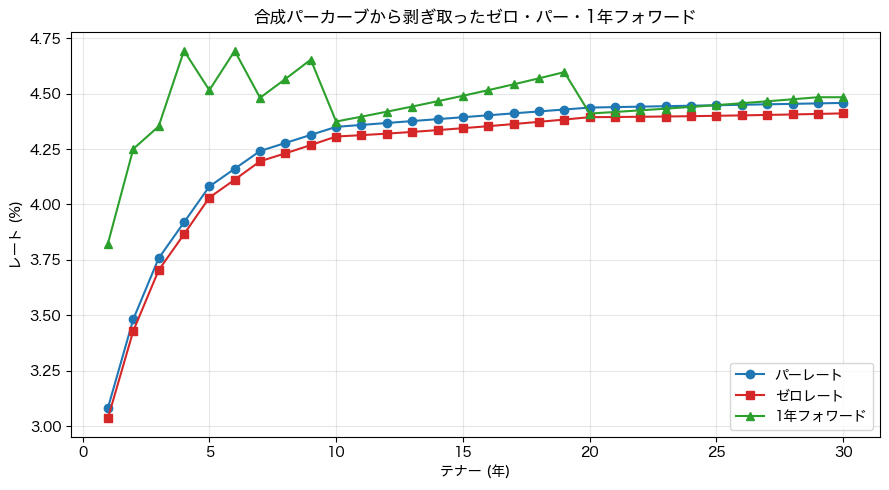

In [12]:
import matplotlib.pyplot as plt

import matplotlib.font_manager as _fm
for _f in ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Noto Sans JP", "TakaoPGothic", "IPAPGothic"]:
    if any(_f == _n.name for _n in _fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(annual_grid, ust_par * 100, "o-", label="パーレート", color="#1f77b4")
ax.plot(annual_grid, ust_zero * 100, "s-", label="ゼロレート", color="#d62728")
ax.plot(annual_grid, ust_fwd * 100, "^-", label="1年フォワード", color="#2ca02c")
ax.set_xlabel("テナー (年)")
ax.set_ylabel("レート (%)")
ax.set_title("合成パーカーブから剥ぎ取ったゼロ・パー・1年フォワード")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

右上がりのカーブでは、限界金利であるフォワードが最も高く、単一支払いの利回りであるゼロが
中間、クーポン全体の平均利回りであるパーが最も低い、という順序が保たれる。長期端で
カーブが寝る（パー利回りが頭打ちになる）ため、フォワードは 20 年超で沈み込む。

## 演習

1. 上の合成パーカーブを年1回払いでブートストラップし、ゼロ・パー・1年フォワードの3本を
   1枚のチャートに描け。さらに `bondlab.curve.bootstrap_par` の結果と、時間軸を揃えた
   QuantLib `DiscountCurve` の割引係数が $10^{-12}$ 未満で一致することを示せ。
2. 特定テナー（例：2年）のパー利回りに $+10\,\mathrm{bp}$ のショックを与え、ベースラインとの
   ゼロレート差（bp）をテナー横断でプロットせよ。ショックがどこから立ち上がり、長期ゾーンへ
   どう伝播して残るかを、前進代入の running sum の観点から説明せよ。

解答例は `solutions/S2/sol_0201.py` に置く。

## 用語集

定義の正は `glossary/02_curves.md`。ここでは初出語の一行要約のみ示す。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| [ブートストラップ](../../glossary/02_curves.md#bootstrap) | bootstrap | パー利回り等から割引係数を逐次に剥ぎ取る前進代入の手続き |
| [ゼロカーブ](../../glossary/02_curves.md#zero-curve) | zero curve | 各年限の単一支払いに対するゼロレートを並べたカーブ |
| [フォワードレート](../../glossary/02_curves.md#forward-rate) | forward rate | いま約定し将来区間に適用される金利。ゼロの限界に対応 |
| [パーレート](../../glossary/02_curves.md#par-rate) | par rate | 標準クーポン債が額面で取引されるときのクーポン率 |
| [剥ぎ取り](../../glossary/02_curves.md#strip) | strip | 短期から順に割引係数を確定させていくブートストラップの逐次操作 |